In [1]:
import math
import sys
import time
import matplotlib.pyplot as plt

import aligator

import hppfcl as fcl
import meshcat
import numpy as np
import pinocchio as pin
#import proxsuite_nlp
from pinocchio.visualize import MeshcatVisualizer

In [2]:
BODY_RADIUS = 0.1
BODY_MASS = 1.0
LINK_LENGTH = 1.0

INPUT_REG = 1e-5
TERMINAL_REG = 3

DT = 0.01
TIME_WINDOW = 2.0

In [9]:
def create_models(
    nb_pendulum, body_radius=BODY_RADIUS, body_mass=BODY_MASS, length=LINK_LENGTH
):
    "Set up the inertial and geometry models for a double pendulum."
    # Create models
    model = pin.Model()
    geom_model = pin.GeometryModel()

    parent_id = 0
    joint_placement = pin.SE3.Identity()

    shape0 = fcl.Sphere(body_radius)
    geom0_obj = pin.GeometryObject("base", 1, shape0, pin.SE3.Identity())  # type: ignore
    geom0_obj.meshColor = np.array([1.0, 0.1, 0.1, 1.0])  # type: ignore
    geom_model.addGeometryObject(geom0_obj)

    for k in range(nb_pendulum):
        joint_name = "joint_" + str(k + 1)
        joint_id = model.addJoint(
            parent_id, pin.JointModelRX(), joint_placement, joint_name
        )

        body_inertia = pin.Inertia.FromSphere(body_mass, body_radius)
        body_placement = joint_placement.copy()
        assert body_placement.translation is not None
        body_placement.translation[2] = length
        model.appendBodyToJoint(joint_id, body_inertia, body_placement)

        geom1_name = "ball_" + str(k + 1)
        shape1 = fcl.Sphere(body_radius)
        geom1_obj = pin.GeometryObject(geom1_name, joint_id, shape1, body_placement)
        geom1_obj.meshColor = np.ones(4)
        geom_model.addGeometryObject(geom1_obj)

        geom2_name = "bar_" + str(k + 1)
        shape2 = fcl.Cylinder(body_radius / 4.0, body_placement.translation[2])
        shape2_placement = body_placement.copy()
        shape2_placement.translation[2] /= 2.0

        geom2_obj = pin.GeometryObject(geom2_name, joint_id, shape2, shape2_placement)
        geom2_obj.meshColor = np.array([0.0, 0.0, 0.0, 1.0])
        geom_model.addGeometryObject(geom2_obj)

        parent_id = joint_id
        joint_placement = body_placement.copy()

    end_frame = pin.Frame(  # end effector
        "ee_frame",
        model.getJointId("joint_" + str(nb_pendulum)),
        0,
        body_placement,
        pin.FrameType(3),
    )
    model.addFrame(end_frame)
    return model, geom_model

In [10]:
def create_aligator_model(nb_pendulum: int, model, dt=DT, time=TIME_WINDOW):
    "Set up an aligator TrajOptProblem and with its dynamics."
    n_steps = math.floor(time / dt)

    space = aligator.manifolds.MultibodyPhaseSpace(model)
    cont_dyn = aligator.dynamics.MultibodyFreeFwdDynamics(space)
    disc_dyn = aligator.dynamics.IntegratorSemiImplEuler(cont_dyn, dt)
    nv = model.nv

    # start position: facing down and stationary
    x0 = space.neutral() 
    x0[0] = np.pi

    rcost = aligator.CostStack(space, nv)

    # running cost regularizes the control input
    w_u = np.ones(nv) * INPUT_REG
    # add cost on control
    rcost.addCost(aligator.QuadraticControlCost(space, np.zeros(nv), np.diag(w_u) * dt))

    # terminal cost to ensure target position
    # target position: upright, static.
    target_pos = np.zeros_like(x0)
    w_x_terminal = np.array([TERMINAL_REG] * nb_pendulum + [0.0] * nb_pendulum)
    term_cost = aligator.CostStack(space, nv)
    term_cost.addCost(
        aligator.QuadraticStateCost(space, nv, target_pos, np.diag(w_x_terminal))
    )

    # solve trajopt problem
    problem = aligator.TrajOptProblem(x0, nv, space, term_cost)
    for i in range(n_steps):
        stage = aligator.StageModel(rcost, disc_dyn)
        problem.addStage(stage)
    return problem, disc_dyn

In [11]:
model, geom_model = create_models(2)
data = model.createData()

prob, disc_dyn = create_aligator_model(2, model)

/var/folders/c2/vhmqh4t566q95zcjystvh20c0000gn/T/ipykernel_20201/1319951764.py:13: UserWarning: This function has been marked as deprecated and will be removed in a future release.
  geom0_obj = pin.GeometryObject("base", 1, shape0, pin.SE3.Identity())  # type: ignore
/var/folders/c2/vhmqh4t566q95zcjystvh20c0000gn/T/ipykernel_20201/1319951764.py:31: UserWarning: This function has been marked as deprecated and will be removed in a future release.
  geom1_obj = pin.GeometryObject(geom1_name, joint_id, shape1, body_placement)
/var/folders/c2/vhmqh4t566q95zcjystvh20c0000gn/T/ipykernel_20201/1319951764.py:40: UserWarning: This function has been marked as deprecated and will be removed in a future release.
  geom2_obj = pin.GeometryObject(geom2_name, joint_id, shape2, shape2_placement)


In [13]:
u0 = np.zeros(disc_dyn.nu)
# initial guesses for the solver?
us_i = [u0] * prob.num_steps  # aligator wants a list as input?
xs_i = aligator.rollout(disc_dyn, prob.x0_init, us_i)

In [87]:
solver = aligator.SolverProxDDP(1e-8, max_iters=2000)
solver.setup(prob)
solver.run(prob, xs_i, us_i)
res = solver.results
print(res)

Results {
  num_iters:    38,
  converged:    true,
  traj. cost:   5.037e-04,
  merit.value:  5.037e-04,
  prim_infeas:  1.536e-10,
  dual_infeas:  7.885e-09,
  al_iters:     3,
}


In [88]:
res_us = np.array(res.us)

In [114]:
res_us.min(), res_us.max()

(np.float64(-11.835813557552692), np.float64(8.899276892268203))

In [121]:
viz = MeshcatVisualizer(model, geom_model, geom_model)
viz.initViewer(loadModel=True)

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7005/static/


In [122]:
def visualize_traj(qs):
    for q in qs:
        viz.display(q)
        time.sleep(DT)

In [180]:
def rollout(prob, us, mod=None):
    "Rollout the control sequence, possibly with modifications to the controls."
    q, v = prob.x0_init[:2].copy(), prob.x0_init[2:].copy()
    qs = [q]

    for i in range(prob.num_steps):
        if mod is not None:
            tau = mod(res_us[i], v)
        else:
            tau = res_us[i]
        a = pin.aba(model, data, q, v, tau)
        v += a * DT
        q = pin.integrate(model, q, v * DT)
        qs.append(q)
    
    return qs

In [181]:
rollout(prob, res_us, lambda u, v: u - 0.1 * v)

[array([3.14159265, 0.        ]),
 array([ 3.14306281, -0.00340381]),
 array([ 3.14619139, -0.01066345]),
 array([ 3.15115442, -0.0222016 ]),
 array([ 3.1581133, -0.0384058]),
 array([ 3.16721097, -0.05961944]),
 array([ 3.17856642, -0.08612846]),
 array([ 3.19226687, -0.11814287]),
 array([ 3.2083582 , -0.15577373]),
 array([ 3.22683401, -0.19900731]),
 array([ 3.2476257 , -0.24768135]),
 array([ 3.27059602, -0.30146992]),
 array([ 3.29553942, -0.35988437]),
 array([ 3.32219127, -0.42229553]),
 array([ 3.35024559, -0.48797618]),
 array([ 3.37937827, -0.55615651]),
 array([ 3.40927091, -0.62608072]),
 array([ 3.43963039, -0.69705361]),
 array([ 3.47020163, -0.76847071]),
 array([ 3.5007732 , -0.83983124]),
 array([ 3.53117707, -0.91073734]),
 array([ 3.56128468, -0.98088446]),
 array([ 3.59100121, -1.0500476 ]),
 array([ 3.62025939, -1.11806649]),
 array([ 3.64901372, -1.18483191]),
 array([ 3.6772355 , -1.25027376]),
 array([ 3.70490866, -1.31435128]),
 array([ 3.7320265 , -1.37704536

In [182]:
viz.viewer.jupyter_cell()

In [183]:
res_us.max(), res_us.min()

(np.float64(8.899276892268203), np.float64(-11.835813557552692))

In [186]:
visualize_traj(rollout(prob, res_us, lambda u, v: u - 0.01 * v))

In [193]:
xs_normal = np.array(rollout(prob, res_us))
xs_damped = np.array(rollout(prob, res_us, lambda u, v: u - .01 * v))

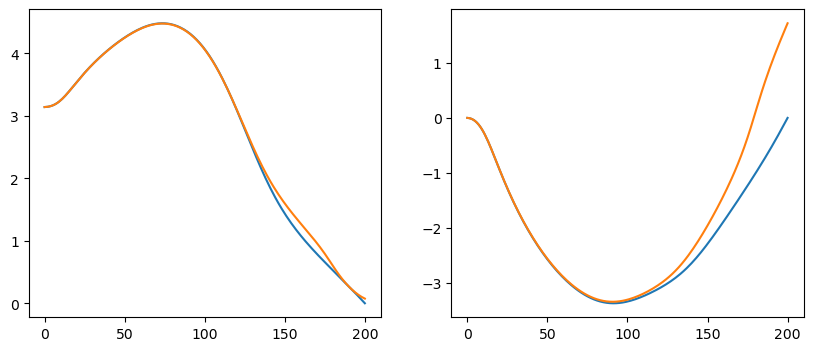

In [198]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(xs_normal[:, 0])
ax[0].plot(xs_damped[:, 0])

ax[1].plot(xs_normal[:, 1])
ax[1].plot(xs_damped[:, 1])